In [1]:
import os, math, random, gc, shutil, sys
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models, datasets
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

In [2]:
DATASET_DIR  = '/kaggle/input/datasets/tommyngx/kneeoa'
TRAIN_DIR    = f'{DATASET_DIR}/train'
VAL_DIR      = f'{DATASET_DIR}/val'
TEST_DIR     = f'{DATASET_DIR}/test'
CKPT_DIR     = '/kaggle/working/'

CLASS_NAMES   = ['0', '1', '2', '3', '4']
DISPLAY_NAMES = [
    'Grade 0 (Healthy)',
    'Grade 1 (Doubtful)',
    'Grade 2 (Minimal)',
    'Grade 3 (Moderate)',
    'Grade 4 (Severe)',
]
NUM_CLASSES = len(CLASS_NAMES)

device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE   = 32
NUM_EPOCHS   = 100
LR           = 1e-3
WEIGHT_DECAY = 1e-4
TEMPERATURE  = 10.0
ALPHA        = 0.5
DROPOUT      = 0.3
SEEDS        = [33, 81, 5]
USE_AMP      = torch.cuda.is_available()

os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device: {device} | AMP: {USE_AMP}")

Device: cuda | AMP: True


In [3]:
def set_seed(seed=30):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


def _compute_mse_rmse(labels, preds):
    labels_arr = np.array(labels, dtype=np.float32)
    preds_arr  = np.array(preds,  dtype=np.float32)
    mse  = float(np.mean((labels_arr - preds_arr) ** 2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(labels_arr - preds_arr)))
    return mse, rmse, mae

In [4]:
def save_resume_ckpt(path, epoch, model, optimizer, scheduler, scaler,
                     history, best_qwk, best_preds, best_labels):
    torch.save({
        'epoch':            epoch,
        'model_state_dict': model.state_dict(),
        'optimizer':        optimizer.state_dict(),
        'scheduler':        scheduler.state_dict(),
        'scaler':           scaler.state_dict() if scaler is not None else None,
        'history':          history,
        'best_qwk':         best_qwk,
        'best_preds':       best_preds,
        'best_labels':      best_labels,
    }, path)


def load_resume_ckpt(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    if scaler is not None and ckpt.get('scaler') is not None:
        scaler.load_state_dict(ckpt['scaler'])
    print(f"  ↺ Resumed from epoch {ckpt['epoch']+1}  "
          f"(best QWK so far: {ckpt['best_qwk']:.4f})")
    return (ckpt['epoch'] + 1, ckpt['history'],
            ckpt['best_qwk'], ckpt['best_preds'], ckpt['best_labels'])


def save_best_weights(path, epoch, model, qwk):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'qwk': qwk}, path)


def _recompute_no_improve(history):
    if not history['val_qwk']:
        return 0
    peak          = max(history['val_qwk'])
    last_peak_idx = max(i for i, v in enumerate(history['val_qwk']) if v == peak)
    return len(history['val_qwk']) - 1 - last_peak_idx

In [5]:
train_tfm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), value='random'),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tfm)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_tfm)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_tfm)

assert train_dataset.classes == CLASS_NAMES, (
    f"Folder classes {train_dataset.classes} don't match CLASS_NAMES {CLASS_NAMES}"
)

train_labels   = [label for _, label in train_dataset.samples]
class_counts   = np.bincount(train_labels, minlength=NUM_CLASSES)
sample_weights = np.array([1.0 / class_counts[lbl] for lbl in train_labels])
sampler = WeightedRandomSampler(
    torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("Class distribution (train):")
for i, name in enumerate(DISPLAY_NAMES):
    n   = class_counts[i]
    bar = '█' * int(30 * n / len(train_dataset))
    print(f"  [{i}] {name:<25s}: {n:4d} ({100*n/len(train_dataset):5.1f}%)  {bar}")

Train: 5778 | Val: 826 | Test: 1656
Class distribution (train):
  [0] Grade 0 (Healthy)        : 2286 ( 39.6%)  ███████████
  [1] Grade 1 (Doubtful)       : 1046 ( 18.1%)  █████
  [2] Grade 2 (Minimal)        : 1516 ( 26.2%)  ███████
  [3] Grade 3 (Moderate)       :  757 ( 13.1%)  ███
  [4] Grade 4 (Severe)         :  173 (  3.0%)  


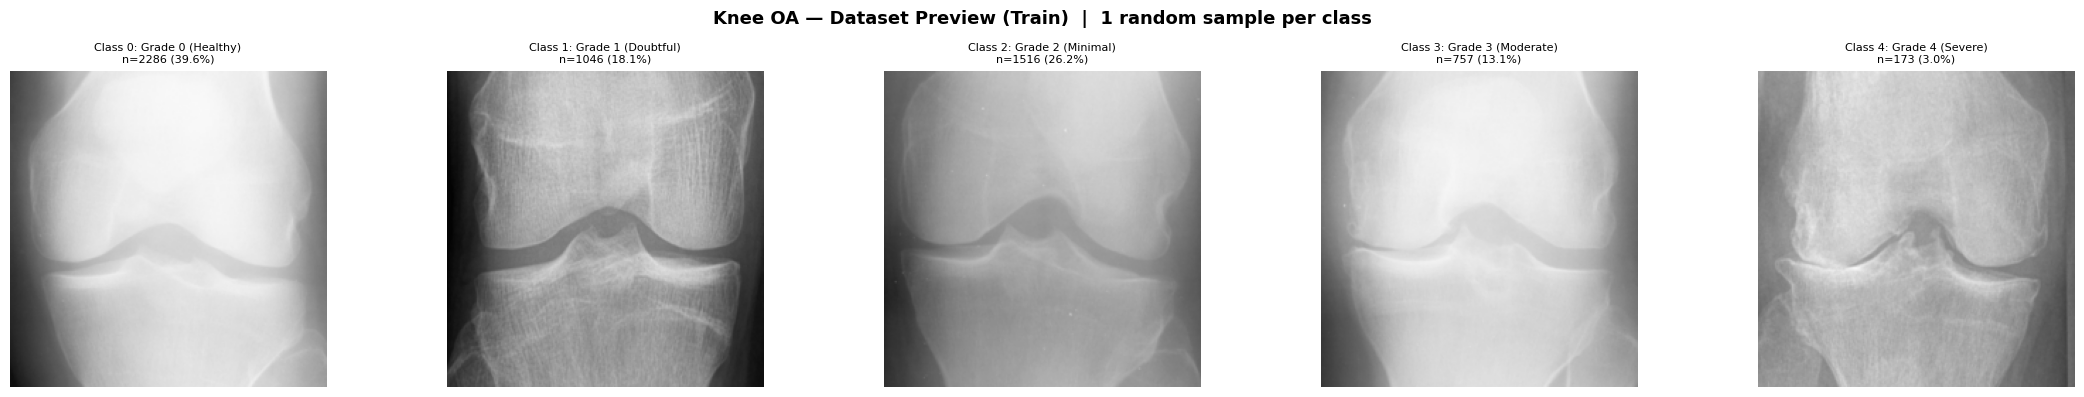

In [6]:
def preview_dataset(dataset, split_name="Train"):
    """Show one random sample per class directly from an ImageFolder dataset."""
    from collections import defaultdict
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(
        f"Knee OA — Dataset Preview ({split_name})  |  1 random sample per class",
        fontsize=13, fontweight='bold'
    )
    cls_to_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        cls_to_indices[label].append(idx)

    for cls_idx, disp_name in enumerate(DISPLAY_NAMES):
        indices = cls_to_indices[cls_idx]
        pick    = random.choice(indices)
        img_path, _ = dataset.samples[pick]
        img = Image.open(img_path).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {disp_name}\nn={len(indices)} "
            f"({100*len(indices)/len(dataset):.1f}%)",
            fontsize=8
        )
        axes[cls_idx].axis('off')

    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()


preview_dataset(train_dataset, "Train")

In [7]:
def analyse_results(results_list, scenario_title, loss_label="Loss",
                    teacher_accs=None, test_results_list=None):
    seeds      = [r['seed'] for r in results_list]
    all_losses = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks   = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs   = np.array([r['history']['val_acc']    for r in results_list])
    all_maes   = np.array([r['history']['val_mae']    for r in results_list], dtype=float)
    epochs     = np.arange(1, all_losses.shape[1] + 1)
    best_res   = max(results_list, key=lambda x: x['qwk'])
    colors     = plt.cm.tab10.colors

    cms = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
           for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    seed_accs = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100
                 for r in results_list]
    seed_maes = [np.mean(np.abs(np.array(r['labels']) - np.array(r['preds'])))
                 for r in results_list]
    mean_acc  = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk  = np.mean([r['qwk'] for r in results_list])
    std_qwk   = np.std([r['qwk']  for r in results_list])
    mean_mae  = np.mean(seed_maes);  std_mae  = np.std(seed_maes)

    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm_avg[i, j] > 0:
                misclass.append((cm_avg[i, j], i, j))
    misclass.sort(reverse=True)

    report   = classification_report(best_res['labels'], best_res['preds'],
                                      target_names=DISPLAY_NAMES, output_dict=True)
    best_acc = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100
    CKPT_SAFE = (scenario_title.replace(' ', '_').replace('/', '_')
                               .replace('(', '').replace(')', ''))

    fig1 = plt.figure(figsize=(24, 20))
    fig1.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                  fontsize=16, fontweight='bold', y=0.99)
    gs1 = gridspec.GridSpec(4, 4, figure=fig1, hspace=0.42, wspace=0.30)

    ax = fig1.add_subplot(gs1[0, 0])
    bp = ax.boxplot([seed_accs], patch_artist=True, widths=0.4,
                    medianprops=dict(color='red', lw=2))
    bp['boxes'][0].set_facecolor('#aec6e8')
    ax.scatter([1] * len(seed_accs), seed_accs, color='black', s=40, zorder=5)
    ax.set_xticks([1]); ax.set_xticklabels(['Student'])
    ax.set_title(f"Val Accuracy Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    ax.text(1, mean_acc, f"μ={mean_acc:.2f}%\nσ={std_acc:.2f}%",
            ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    ax = fig1.add_subplot(gs1[0, 1])
    if teacher_accs:
        names      = [f"Teacher {i+1}" for i in range(len(teacher_accs))] + ['Student']
        values     = list(teacher_accs) + [mean_acc]
        bar_colors = ['#4878CF'] * len(teacher_accs) + ['#F8A60B']
        bars = ax.bar(range(len(names)), values, color=bar_colors,
                      width=0.5, edgecolor='white', lw=1.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
        ax.set_ylim(min(values) - 5, 100)
        ax.set_title("Teacher vs Student Accuracy", fontsize=11, fontweight='bold')
        ax.set_ylabel("Accuracy (%)")
    else:
        seed_qwks = [r['qwk'] for r in results_list]
        bp2 = ax.boxplot([seed_qwks], patch_artist=True, widths=0.4,
                         medianprops=dict(color='red', lw=2))
        bp2['boxes'][0].set_facecolor('#b8d4a8')
        ax.scatter([1] * len(seed_qwks), seed_qwks, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(f"Val QWK Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Quadratic Weighted Kappa")
        ax.text(1, mean_qwk, f"μ={mean_qwk:.4f}\nσ={std_qwk:.4f}",
                ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[0, 2])
    bp3 = ax.boxplot([seed_maes], patch_artist=True, widths=0.4,
                     medianprops=dict(color='red', lw=2))
    bp3['boxes'][0].set_facecolor('#f4c2c2')
    ax.scatter([1] * len(seed_maes), seed_maes, color='black', s=40, zorder=5)
    ax.set_xticks([1]); ax.set_xticklabels(['Student'])
    ax.set_title(f"Val MAE Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Mean Absolute Error")
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    ax.text(1, mean_mae, f"μ={mean_mae:.4f}\nσ={std_mae:.4f}",
            ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    ax = fig1.add_subplot(gs1[0, 3])
    mean_l = all_losses.mean(0); std_l = all_losses.std(0)
    ax.plot(epochs, mean_l, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, mean_l - std_l, mean_l + std_l, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss Value")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[1, 0])
    mean_a = all_accs.mean(0) * 100; std_a = all_accs.std(0) * 100
    ax.plot(epochs, mean_a, color='#1f77b4', lw=2.2, label='Mean')
    ax.fill_between(epochs, mean_a - std_a, mean_a + std_a,
                    alpha=0.25, color='#1f77b4', label='±1 std')
    ax.set_title("Validation Accuracy Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[1, 1])
    mean_q = all_qwks.mean(0); std_q = all_qwks.std(0)
    ax.plot(epochs, mean_q, color='#2ca02c', lw=2.2, label='Mean')
    ax.fill_between(epochs, mean_q - std_q, mean_q + std_q,
                    alpha=0.25, color='#2ca02c', label='±1 std')
    ax.set_title("Validation QWK Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("QWK")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax    = fig1.add_subplot(gs1[1, 2])
    valid = ~np.isnan(all_maes).all(axis=0)
    mean_m = np.nanmean(all_maes, axis=0); std_m = np.nanstd(all_maes, axis=0)
    ax.plot(epochs[valid], mean_m[valid], color='#d62728', lw=2.2, label='Mean')
    ax.fill_between(epochs[valid], (mean_m - std_m)[valid], (mean_m + std_m)[valid],
                    alpha=0.25, color='#d62728', label='±1 std')
    ax.set_title("Validation MAE Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[1, 3])
    ratio = all_qwks.mean(0) / (all_losses.mean(0) + 1e-8)
    ax.plot(epochs, ratio, color='purple', lw=1.8)
    ax.set_title("QWK / Loss Ratio Over Training", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("QWK / Loss Ratio")
    ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[2, 0])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a * 100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs, mean_a, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Run Validation Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[2, 1])
    for i, r in enumerate(results_list):
        maes_run = [m for m in r['history']['val_mae'] if m is not None]
        ep_run   = epochs[:len(maes_run)]
        ax.plot(ep_run, maes_run, color=colors[i], lw=1.5, alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs[valid], mean_m[valid], 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Run MAE Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[2, 2])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Raw Counts)", fontsize=11, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=8,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    ax = fig1.add_subplot(gs1[2, 3])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Normalized)", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=7.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    ax = fig1.add_subplot(gs1[3, 0])
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc * 100,
                  color='#aec6e8', edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy\n(from Averaged CM)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[3, 1])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix\nStandard Deviation", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center',
                    fontsize=7.5, color='black')

    ax = fig1.add_subplot(gs1[3, 2])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=11, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=8,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    ax = fig1.add_subplot(gs1[3, 3])
    f1_scores = [report[disp]['f1-score'] for disp in DISPLAY_NAMES]
    f1_bars   = ax.bar(range(NUM_CLASSES), [f * 100 for f in f1_scores],
                       color='#b8d4a8', edgecolor='grey', lw=0.8)
    for bar, val in zip(f1_bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 Score\n(Best Seed)", fontsize=11, fontweight='bold')
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    fig1.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    fig2 = plt.figure(figsize=(20, 20))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.55])

    ax = fig2.add_subplot(gs2[0, 0])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Raw Counts)", fontsize=12, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=9,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    ax = fig2.add_subplot(gs2[0, 1])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=8.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    ax = fig2.add_subplot(gs2[1, 0])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix Standard Deviation", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center',
                    fontsize=8.5, color='black')

    ax = fig2.add_subplot(gs2[1, 1])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=12, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=9,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')

    best_mae = np.mean(np.abs(np.array(best_res['labels']) - np.array(best_res['preds'])))
    lines = []
    lines.append("=" * 84)
    lines.append(f"  PERFORMANCE SUMMARY — {scenario_title}")
    lines.append("=" * 84)
    lines.append(f"  Seeds trained              : {seeds}")
    lines.append(f"  Val Accuracy  (mean ± std) : {mean_acc:.2f}%  ±  {std_acc:.2f}%"
                 f"  [range: {min(seed_accs):.2f}% – {max(seed_accs):.2f}%]")
    lines.append(f"  Val QWK       (mean ± std) : {mean_qwk:.4f}  ±  {std_qwk:.4f}"
                 f"  [range: {min(r['qwk'] for r in results_list):.4f} – "
                 f"{max(r['qwk'] for r in results_list):.4f}]")
    lines.append(f"  Val MAE       (mean ± std) : {mean_mae:.4f}  ±  {std_mae:.4f}"
                 f"  [range: {min(seed_maes):.4f} – {max(seed_maes):.4f}]")
    lines.append(f"  Best seed                  : Seed {best_res['seed']}"
                 f"  (QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%, MAE={best_mae:.4f})")
    lines.append(f"  Final train loss (mean)    : {all_losses[:, -1].mean():.4f}"
                 f"  ±  {all_losses[:, -1].std():.4f}")
    lines.append(f"  Peak QWK epoch  (mean)     : "
                 f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}")
    lines.append("")
    lines.append("  Per-class Performance (best seed):")
    lines.append(f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
                 f"{'F1-Score':>9s}  {'Support':>7s}")
    lines.append("  " + "-" * 60)
    for cls, disp in zip(CLASS_NAMES, DISPLAY_NAMES):
        d = report[disp]
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                     f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}")
    lines.append("  " + "-" * 60)
    lines.append(f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
                 f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}")
    lines.append(f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
                 f"{report['macro avg']['recall']:>9.3f}  "
                 f"{report['macro avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append(f"  {'Weighted Avg F1':<20s}  {report['weighted avg']['precision']:>9.3f}  "
                 f"{report['weighted avg']['recall']:>9.3f}  "
                 f"{report['weighted avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append("")
    lines.append("  Top-5 Most Common Misclassifications (averaged across seeds):")
    for rank, (count, true_c, pred_c) in enumerate(misclass[:5], 1):
        pct = count / cm_avg.sum(axis=1)[true_c] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[true_c]:<20s} → "
                     f"Predicted={CLASS_NAMES[pred_c]:<20s}"
                     f"  (avg count={count:.1f}, {pct:.1f}% of true class)")
    lines.append("")
    lines.append("  Class Performance Range (per-class accuracy from averaged CM):")
    cls_accs_sorted = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines.append(f"    Best  : {cls_accs_sorted[0][1]}  ({cls_accs_sorted[0][0]*100:.1f}%)")
    lines.append(f"    Worst : {cls_accs_sorted[-1][1]}  ({cls_accs_sorted[-1][0]*100:.1f}%)")
    lines.append(f"    Range : {cls_accs_sorted[-1][0]*100:.1f}% – {cls_accs_sorted[0][0]*100:.1f}%"
                 f"  (gap = {(cls_accs_sorted[0][0]-cls_accs_sorted[-1][0])*100:.1f}pp)")

    if test_results_list:
        test_qwks  = [r['qwk']        for r in test_results_list]
        test_accs  = [r['acc'] * 100  for r in test_results_list]
        test_rmses = [r['rmse']       for r in test_results_list]
        test_maes  = [r['mae']        for r in test_results_list]
        test_mses  = [r['mse']        for r in test_results_list]

        lines.append("")
        lines.append("=" * 84)
        lines.append("  TEST SET EVALUATION")
        lines.append("=" * 84)
        lines.append(f"  {'Seed':<8s}  {'QWK':>8s}  {'Accuracy':>10s}  "
                     f"{'MSE':>8s}  {'RMSE':>8s}  {'MAE':>8s}")
        lines.append("  " + "-" * 62)
        for r in test_results_list:
            lines.append(f"  {r['seed']:<8d}  {r['qwk']:>8.4f}  "
                         f"{r['acc']*100:>9.2f}%  {r['mse']:>8.4f}  "
                         f"{r['rmse']:>8.4f}  {r['mae']:>8.4f}")
        lines.append("  " + "-" * 62)
        lines.append(f"  {'Mean':<8s}  {np.mean(test_qwks):>8.4f}  "
                     f"{np.mean(test_accs):>9.2f}%  {np.mean(test_mses):>8.4f}  "
                     f"{np.mean(test_rmses):>8.4f}  {np.mean(test_maes):>8.4f}")
        lines.append(f"  {'Std':<8s}  {np.std(test_qwks):>8.4f}  "
                     f"{np.std(test_accs):>9.2f}%  {np.std(test_mses):>8.4f}  "
                     f"{np.std(test_rmses):>8.4f}  {np.std(test_maes):>8.4f}")
        lines.append(f"  {'Min':<8s}  {min(test_qwks):>8.4f}  "
                     f"{min(test_accs):>9.2f}%  {min(test_mses):>8.4f}  "
                     f"{min(test_rmses):>8.4f}  {min(test_maes):>8.4f}")
        lines.append(f"  {'Max':<8s}  {max(test_qwks):>8.4f}  "
                     f"{max(test_accs):>9.2f}%  {max(test_mses):>8.4f}  "
                     f"{max(test_rmses):>8.4f}  {max(test_maes):>8.4f}")

    lines.append("=" * 84)

    summary_text = '\n'.join(lines)
    ax_txt.text(0.01, 0.99, summary_text, transform=ax_txt.transAxes,
                fontsize=7.8, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.9, edgecolor='#dee2e6'))

    fig2.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()

    print('\n'.join(lines))

In [8]:
def get_resnet50_teacher():
    m    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m


def get_efficientnet_b3_teacher():
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m


def get_mobilenet_student(dropout=DROPOUT):
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    m.classifier[2]  = nn.Dropout(p=dropout, inplace=True)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

In [9]:
def evaluate_on_test(model, loader):
    model.eval()
    t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            t_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds  = np.array(t_preds)
    t_labels = np.array(t_labels)
    return {
        'qwk':    float(cohen_kappa_score(t_labels, t_preds, weights='quadratic')),
        'acc':    float(np.mean(t_labels == t_preds)),
        'mse':    float(np.mean((t_labels - t_preds) ** 2)),
        'rmse':   float(np.sqrt(np.mean((t_labels - t_preds) ** 2))),
        'mae':    float(np.mean(np.abs(t_labels - t_preds))),
        'preds':  t_preds.tolist(),
        'labels': t_labels.tolist(),
    }

In [10]:
def train_teacher_ce(model, name, save_path, seed=33):
    resume_path = save_path.replace('.pth', '_resume.pth')
    set_seed(seed)
    model  = model.to(device)
    opt    = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, model, opt, sched, scaler)
        if 'val_mae'  not in history: history['val_mae']  = [None] * len(history['val_qwk'])
        if 'val_rmse' not in history: history['val_rmse'] = [None] * len(history['val_qwk'])

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    loss = F.cross_entropy(model(imgs), labels)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                loss = F.cross_entropy(model(imgs), labels)
                loss.backward(); opt.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        model.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())

        v_preds_arr  = np.array(v_preds)
        v_labels_arr = np.array(v_labels)
        qwk  = cohen_kappa_score(v_labels_arr, v_preds_arr, weights='quadratic')
        acc  = np.mean(v_labels_arr == v_preds_arr)
        mse, rmse, mae = _compute_mse_rmse(v_labels_arr, v_preds_arr)

        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mae'].append(mae)
        history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(save_path, epoch + 1, model, best_qwk)

        save_resume_ckpt(resume_path, epoch, model, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    model.load_state_dict(
        torch.load(save_path, map_location=device, weights_only=False)['model_state_dict'])
    model.eval()
    print(f"  {name} best val QWK: {best_qwk:.4f}")
    return model

In [11]:
def train_student(student, seed, t1_model, t2_model,
                  alpha=ALPHA, temperature=TEMPERATURE):
    best_path   = f'{CKPT_DIR}/kd_seed{seed}_best.pth'
    resume_path = f'{CKPT_DIR}/kd_seed{seed}_resume.pth'

    student = student.to(device)
    t1_ref  = t1_model.to(device).eval()
    t2_ref  = t2_model.to(device).eval()
    for p in list(t1_ref.parameters()) + list(t2_ref.parameters()):
        p.requires_grad_(False)

    opt    = optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)
        if 'val_mae'  not in history: history['val_mae']  = [None] * len(history['val_qwk'])
        if 'val_rmse' not in history: history['val_rmse'] = [None] * len(history['val_qwk'])

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    s_l   = student(imgs)
                    t1_l  = t1_ref(imgs).detach()
                    t2_l  = t2_ref(imgs).detach()

                    p_avg = (F.softmax(t1_l / temperature, dim=1) +
                             F.softmax(t2_l / temperature, dim=1)) / 2.0

                    s_log = F.log_softmax(s_l / temperature, dim=1)
                    kl    = ((p_avg * (p_avg.log() - s_log)).sum(dim=1)
                             * (temperature ** 2)).clamp(max=10.0)
                    loss  = (1 - alpha) * F.cross_entropy(s_l, labels) + alpha * kl.mean()
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                s_l   = student(imgs)
                t1_l  = t1_ref(imgs).detach()
                t2_l  = t2_ref(imgs).detach()

                p_avg = (F.softmax(t1_l / temperature, dim=1) +
                         F.softmax(t2_l / temperature, dim=1)) / 2.0

                s_log = F.log_softmax(s_l / temperature, dim=1)
                kl    = ((p_avg * (p_avg.log() - s_log)).sum(dim=1)
                         * (temperature ** 2)).clamp(max=10.0)
                loss  = (1 - alpha) * F.cross_entropy(s_l, labels) + alpha * kl.mean()
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(student(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())

        v_preds_arr  = np.array(v_preds)
        v_labels_arr = np.array(v_labels)
        qwk  = cohen_kappa_score(v_labels_arr, v_preds_arr, weights='quadratic')
        acc  = np.mean(v_labels_arr == v_preds_arr)
        mse, rmse, mae = _compute_mse_rmse(v_labels_arr, v_preds_arr)

        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mae'].append(mae)
        history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(best_path, epoch + 1, student, best_qwk)

        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(
        torch.load(best_path, map_location=device, weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed, 'model': student}

In [12]:
results_kd       = []
trained_students = []

print("\n  Training Teacher ResNet-50 (CE)\n")
set_seed(33)
t1 = train_teacher_ce(get_resnet50_teacher(), "ResNet-50",
                      f"{CKPT_DIR}/kd_teacher_resnet50.pth", seed=33)
cleanup_memory()

print("\n  Training Teacher EfficientNet-B3 (CE)\n")
set_seed(33)
t2 = train_teacher_ce(get_efficientnet_b3_teacher(), "EfficientNet-B3",
                      f"{CKPT_DIR}/kd_teacher_efficientnet_b3.pth", seed=33)
cleanup_memory()

teacher_qwks = [
    evaluate_on_test(t1, val_loader)['qwk'] * 100,
    evaluate_on_test(t2, val_loader)['qwk'] * 100,
]

for seed in SEEDS:
    set_seed(seed)
    print(f"\n  Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)  |  Seed {seed}\n")
    res = train_student(get_mobilenet_student(), seed, t1, t2)
    results_kd.append(res)
    best_student_path = f'{CKPT_DIR}/kd_seed{seed}_best.pth'
    student_for_test  = get_mobilenet_student().to(device)
    student_for_test.load_state_dict(
        torch.load(best_student_path, map_location=device, weights_only=False)['model_state_dict'])
    trained_students.append(student_for_test)
    cleanup_memory()


  Training Teacher ResNet-50 (CE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


  ↺ Resumed from epoch 100  (best QWK so far: 0.8046)
  ResNet-50 best val QWK: 0.8046

  Training Teacher EfficientNet-B3 (CE)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 138MB/s] 


  ↺ Resumed from epoch 100  (best QWK so far: 0.8367)
  EfficientNet-B3 best val QWK: 0.8367

  Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)  |  Seed 33

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 146MB/s]


  ↺ Resumed from epoch 100  (best QWK so far: 0.8069)

  Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)  |  Seed 81

  ↺ Resumed from epoch 100  (best QWK so far: 0.8118)

  Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)  |  Seed 5

  ↺ Resumed from epoch 100  (best QWK so far: 0.8018)


In [13]:
test_results_kd = []
for seed, student_model, res in zip(SEEDS, trained_students, results_kd):
    print(f"Evaluating test set — Seed {seed}")
    t_res            = evaluate_on_test(student_model, test_loader)
    t_res['seed']    = seed
    t_res['history'] = res['history']
    test_results_kd.append(t_res)
    print(f"  Test QWK={t_res['qwk']:.4f} | Acc={t_res['acc']*100:.2f}% | "
          f"RMSE={t_res['rmse']:.4f} | MAE={t_res['mae']:.4f}")

Evaluating test set — Seed 33
  Test QWK=0.8226 | Acc=63.22% | RMSE=0.6872 | MAE=0.4022
Evaluating test set — Seed 81
  Test QWK=0.8273 | Acc=65.82% | RMSE=0.6981 | MAE=0.3895
Evaluating test set — Seed 5
  Test QWK=0.8084 | Acc=61.96% | RMSE=0.7315 | MAE=0.4312


/tmp/ipykernel_58/3446881146.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0, 1, 0.97])


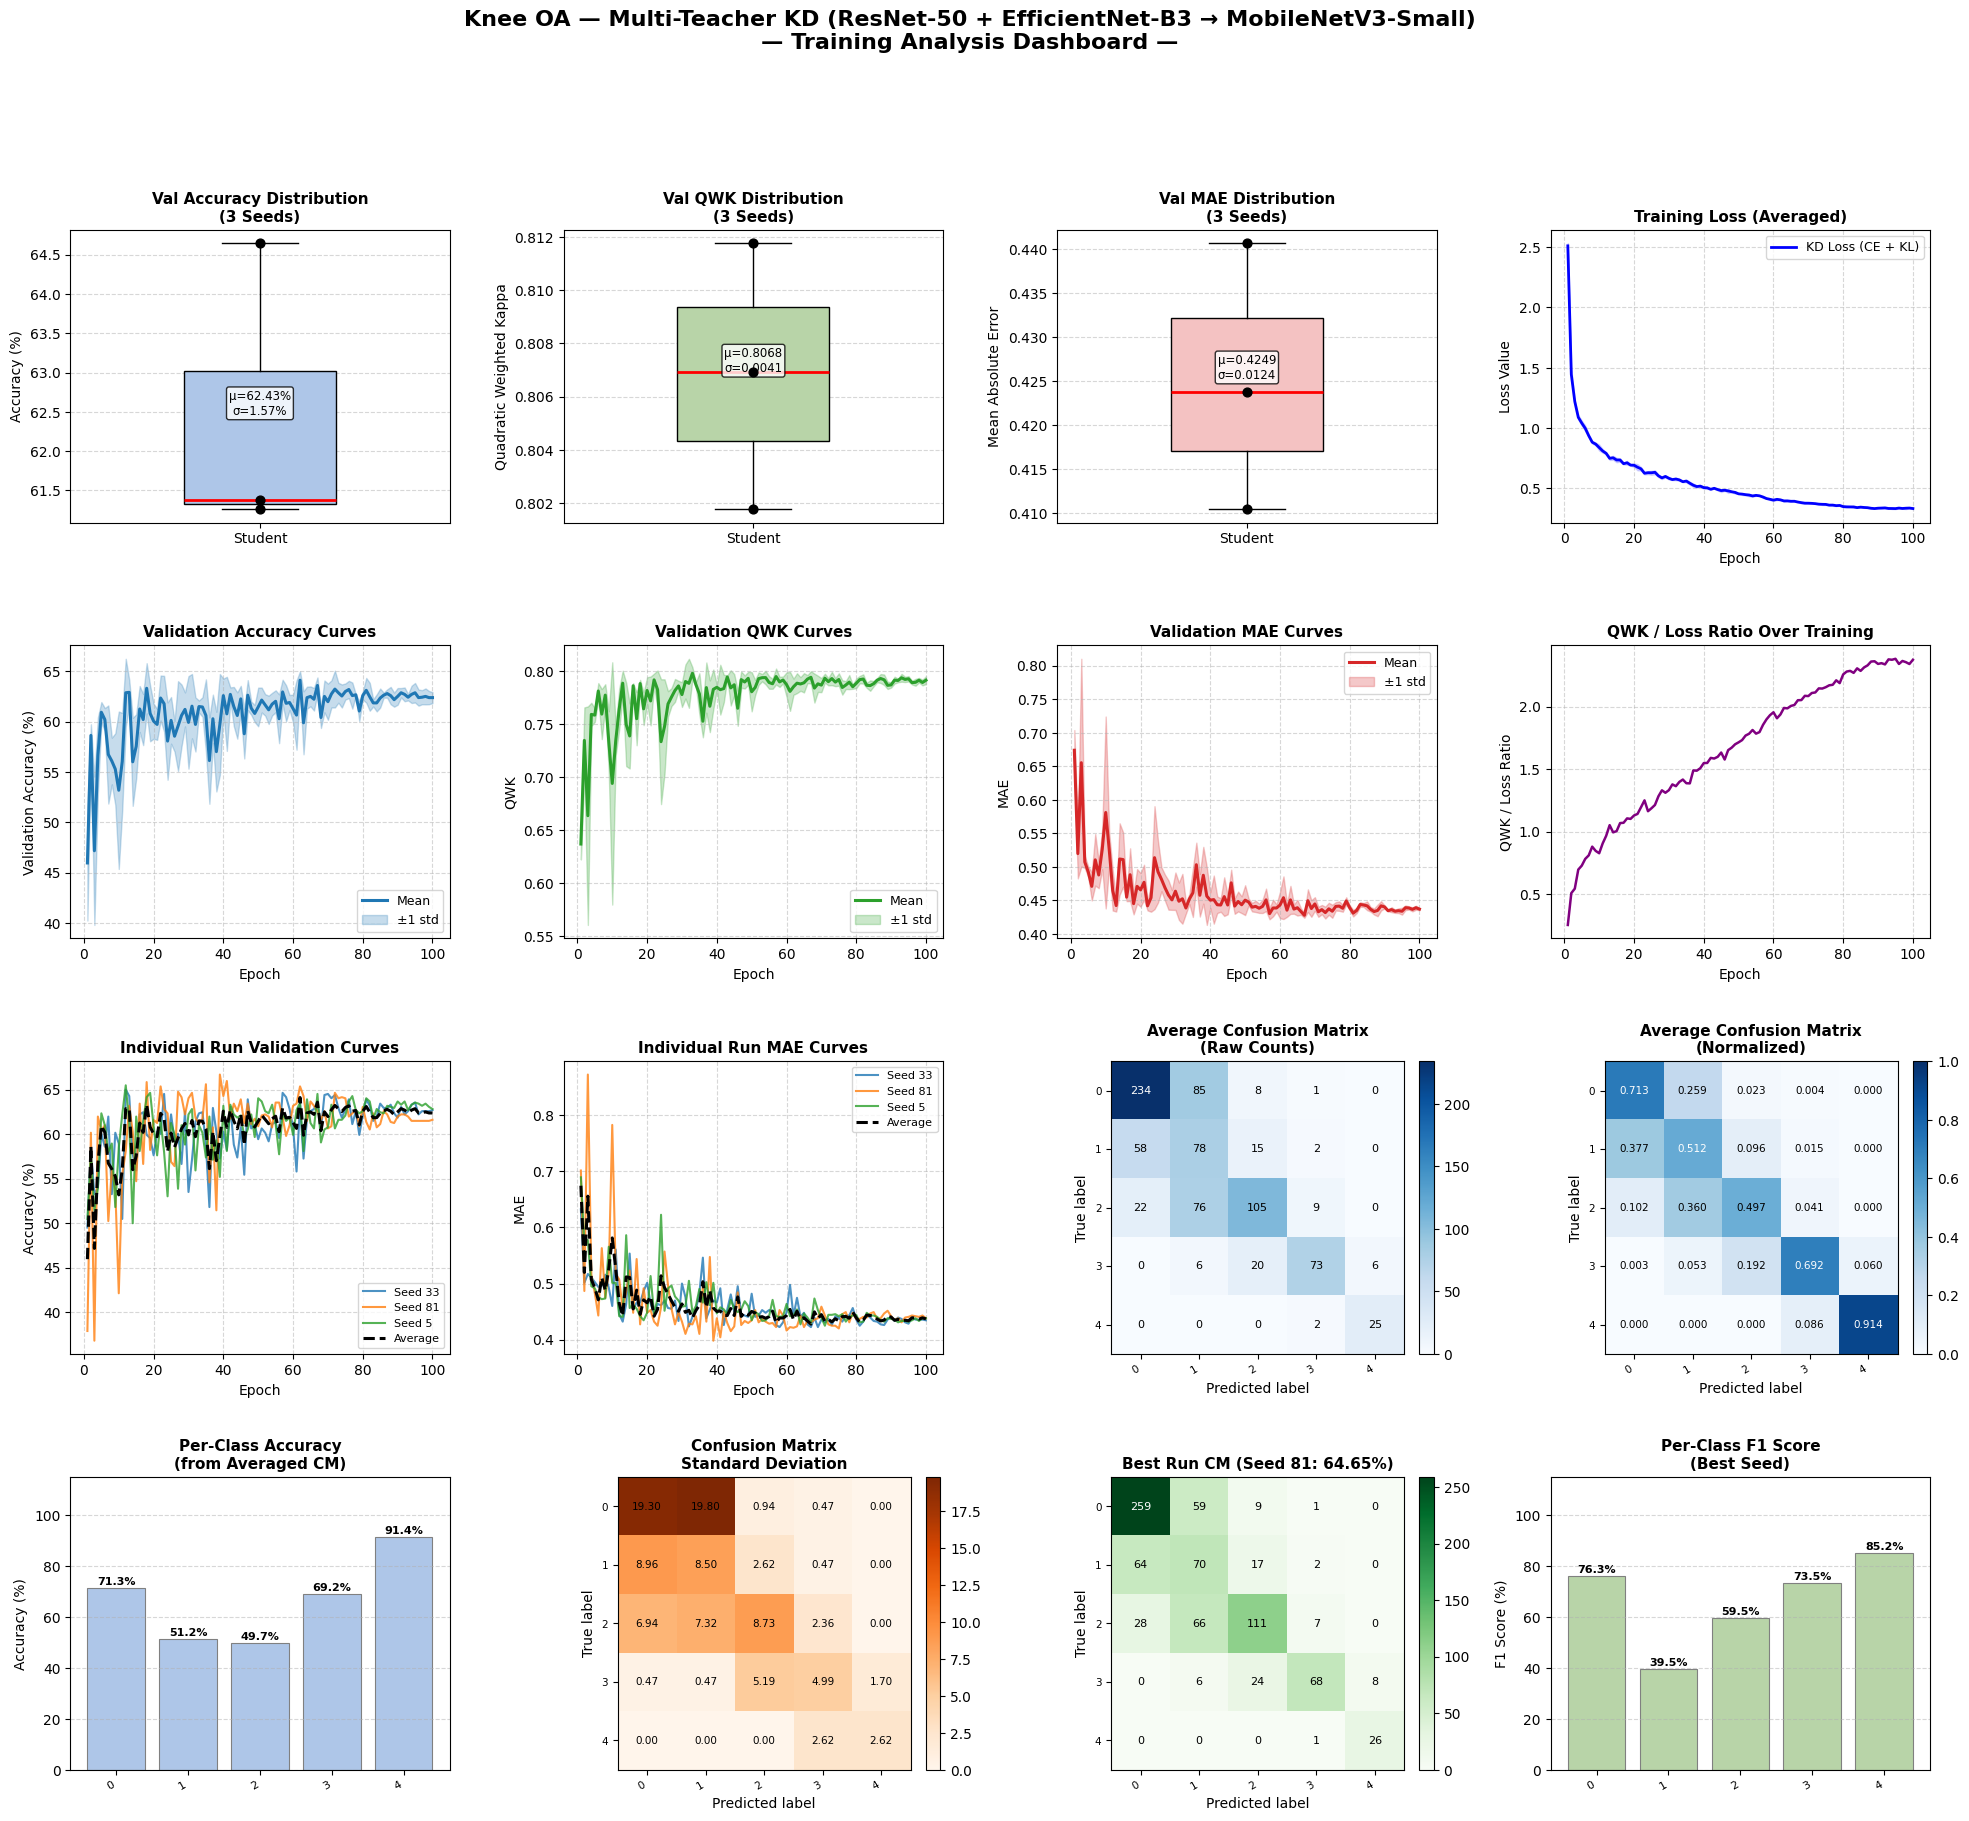

/tmp/ipykernel_58/3446881146.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(rect=[0, 0, 1, 0.97])


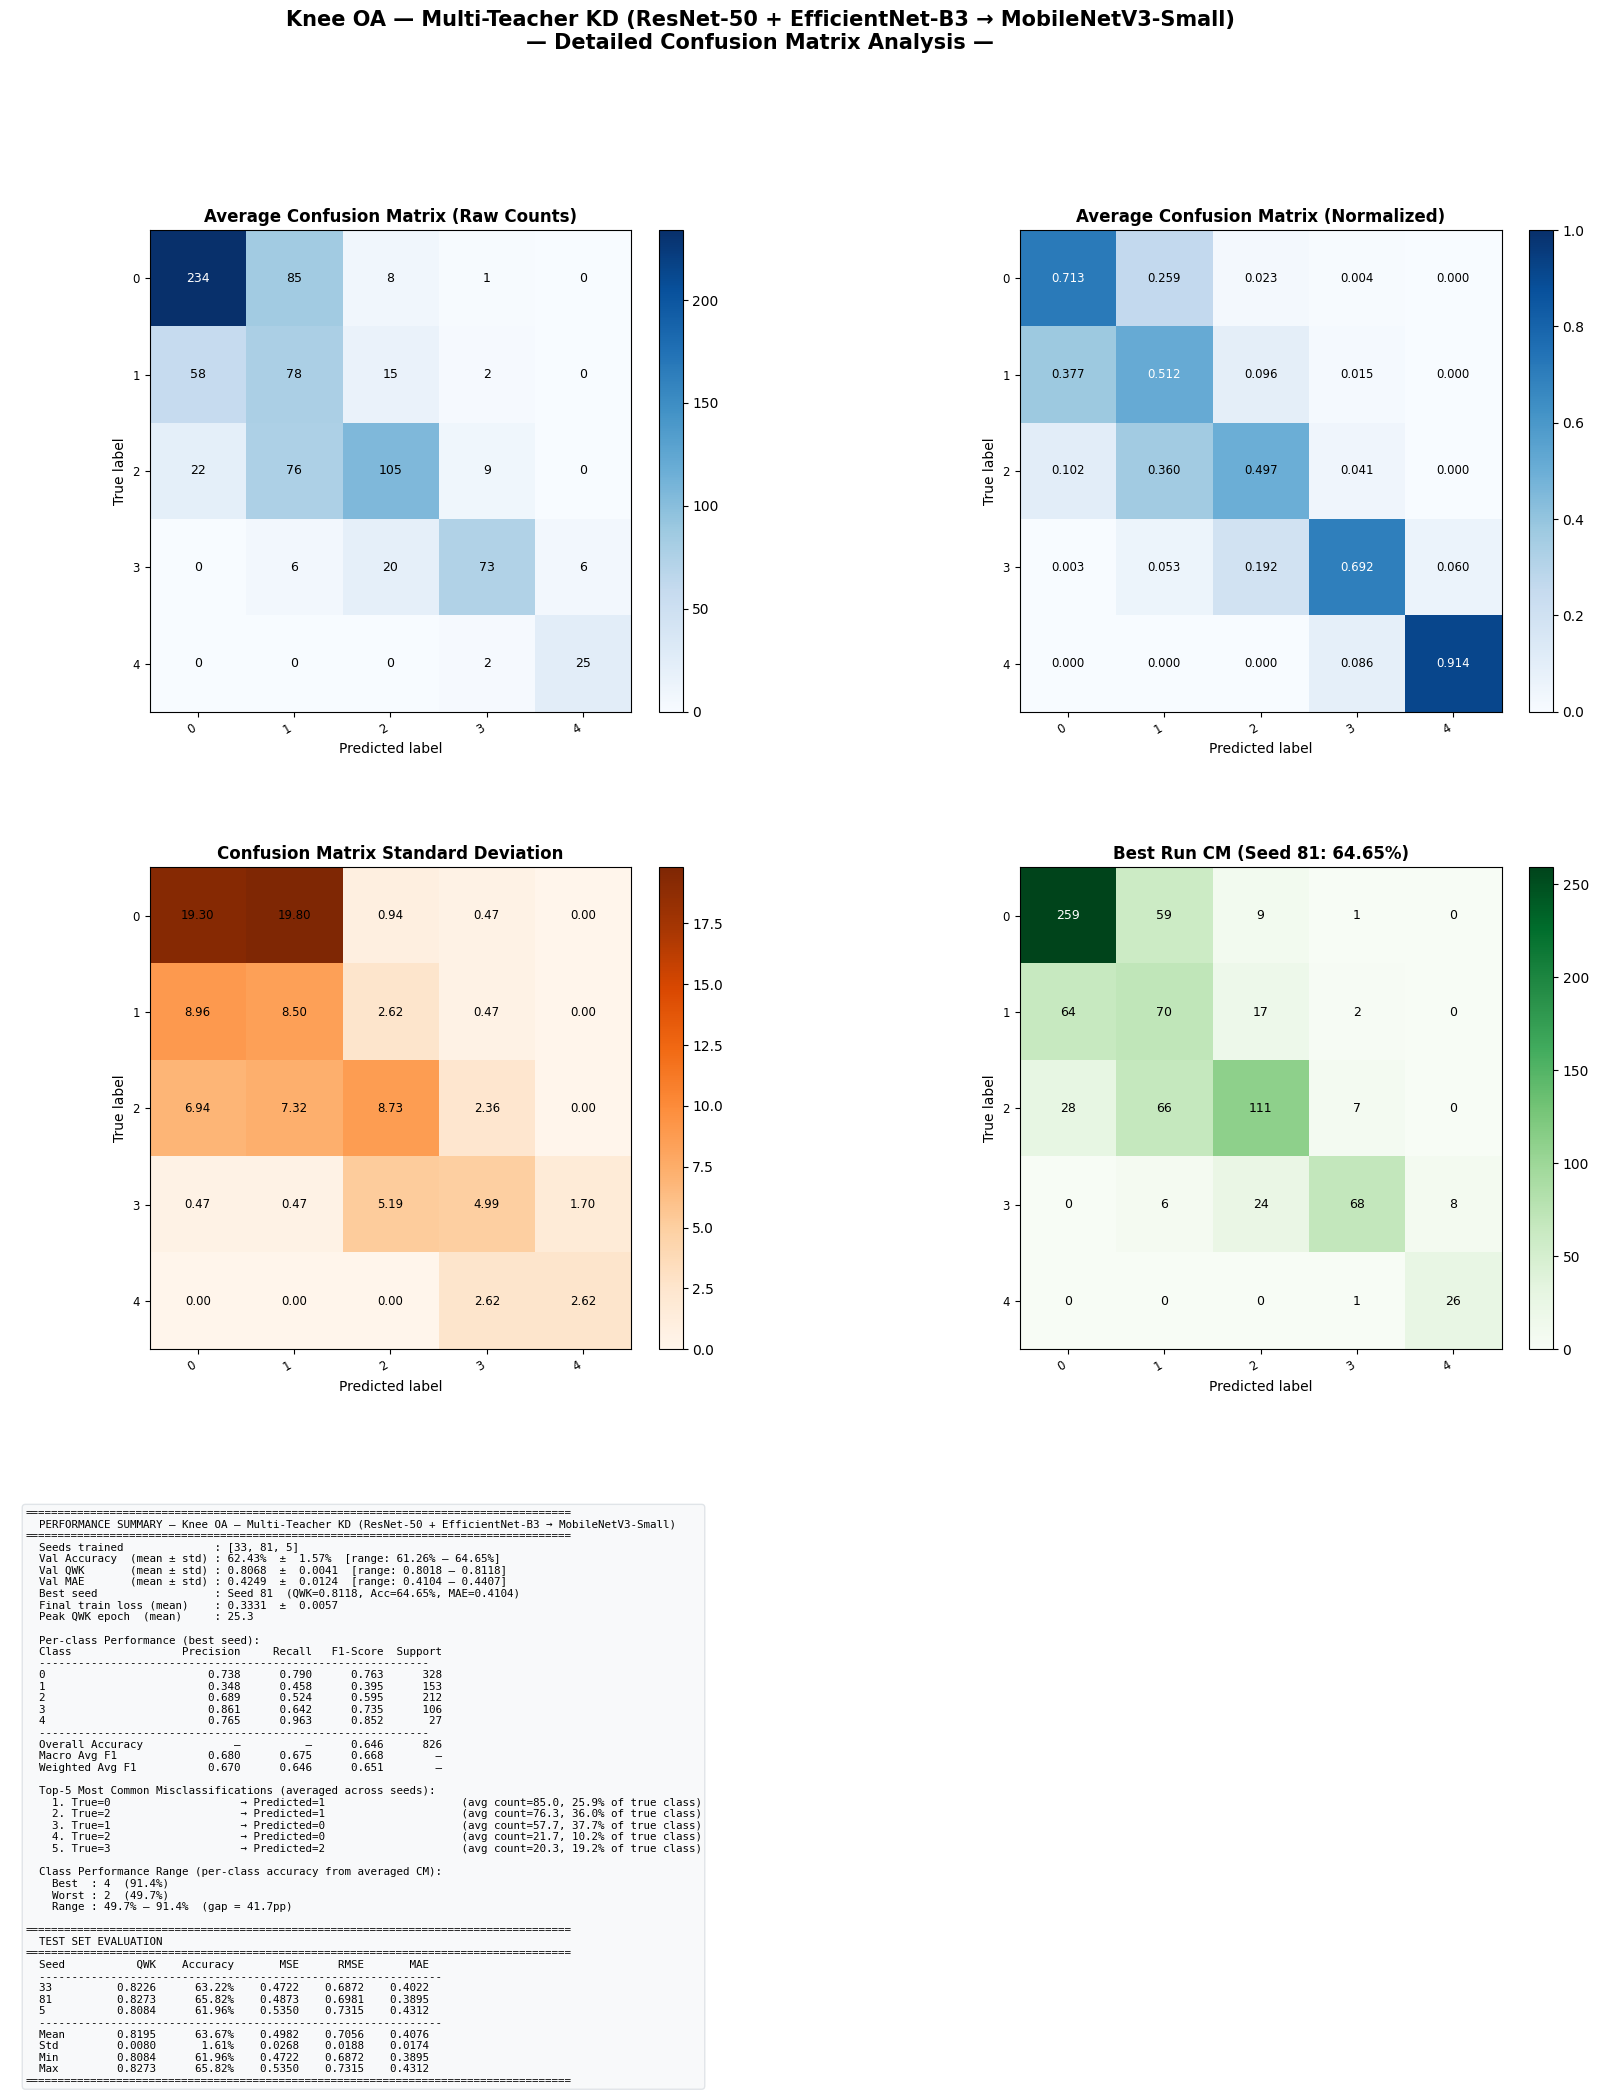

  PERFORMANCE SUMMARY — Knee OA — Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)
  Seeds trained              : [33, 81, 5]
  Val Accuracy  (mean ± std) : 62.43%  ±  1.57%  [range: 61.26% – 64.65%]
  Val QWK       (mean ± std) : 0.8068  ±  0.0041  [range: 0.8018 – 0.8118]
  Val MAE       (mean ± std) : 0.4249  ±  0.0124  [range: 0.4104 – 0.4407]
  Best seed                  : Seed 81  (QWK=0.8118, Acc=64.65%, MAE=0.4104)
  Final train loss (mean)    : 0.3331  ±  0.0057
  Peak QWK epoch  (mean)     : 25.3

  Per-class Performance (best seed):
  Class                 Precision     Recall   F1-Score  Support
  ------------------------------------------------------------
  0                         0.738      0.790      0.763      328
  1                         0.348      0.458      0.395      153
  2                         0.689      0.524      0.595      212
  3                         0.861      0.642      0.735      106
  4                         0.765      0.963

In [14]:
analyse_results(
    results_kd,
    "Knee OA — Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)",
    loss_label="KD Loss (CE + KL)",
    test_results_list=test_results_kd
)